# Notebook 04 — Automatic Speech Recognition (ASR)

This is the **fourth stage** of the meeting-transcription pipeline.

### What this notebook does

| Step | Description | Output |
|------|-------------|--------|
| 1 | Load reconstructed meeting audio and VAD segments from notebook 01 | waveform + segment list |
| 2 | Run **Whisper `base`** on every VAD segment; offset timestamps to meeting-absolute time | primary transcript list |
| 3 | Compare with **Whisper `tiny`** — same segments, lighter model — to illustrate speed/quality trade-off | comparison table + timing chart |
| 4 | Save the primary transcripts to disk for notebook 05 (integration) | `output/asr/EN2001a_asr.json` |

### Design decisions

* **Segment-level transcription** — we pass each VAD segment's audio slice to Whisper individually (rather than the full meeting waveform).  This keeps speaker turns isolated and avoids one long audio stream where Whisper might drift.
* **Timestamp offset** — Whisper returns timestamps *relative to the clip start*.  We add the segment's `start_s` to produce meeting-absolute timecodes, so the output integrates directly with notebook 05.
* **Two models** — `tiny` (39 M params, fastest) and `base` (74 M params, good English quality) are both pretrained on the same multilingual dataset; comparing them isolates the effect of model capacity.
* `language="en"` is forced throughout — EN2001a is English-only and skipping language detection saves ~0.3 s per segment.
* `condition_on_previous_text=False` — since each clip is transcribed independently there is no prior context to condition on; leaving it enabled causes Whisper to hallucinate continuations.


---
## Step 0 — Setup

`openai-whisper` was added via `uv add openai-whisper`.
All other dependencies (`soundfile`, `numpy`, `pandas`, `matplotlib`) are already present.


In [1]:
import json
import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import soundfile as sf
import whisper
import torch
from pathlib import Path
from IPython.display import Audio, display

# Whisper should run on MPS (Apple Silicon) or CPU; never needs fp16 here
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
USE_FP16 = torch.cuda.is_available()   # fp16 only reliable on CUDA

print(f"Torch device   : {DEVICE}")
print(f"Whisper fp16   : {USE_FP16}")
print(f"Whisper models : {whisper.available_models()[:7]} …")


Torch device   : cpu
Whisper fp16   : False
Whisper models : ['tiny.en', 'tiny', 'base.en', 'base', 'small.en', 'small', 'medium.en'] …


---
## Step 1 — Load Inputs from Notebook 01

We read:
1. `output/vad/EN2001a_vad_segments.json` — the segment timestamps produced by notebook 01
2. The per-utterance WAV files under `output/meetings/EN2001a/` — reconstructed into one continuous waveform (identical procedure to notebook 01, self-contained here per the modular design principle).


In [2]:
# ── Paths & constants ──────────────────────────────────────────────────────────
MEETING_ID     = "EN2001a"
MEETING_DIR    = Path(f"output/meetings/{MEETING_ID}")
VAD_FILE       = Path(f"output/vad/{MEETING_ID}_vad_segments.json")
ASR_OUT        = Path("output/asr")
ASR_OUT.mkdir(parents=True, exist_ok=True)

# Segments shorter than this are too brief for reliable ASR — skip them
MIN_SEG_S = 0.5

# ── Load VAD output from notebook 01 ──────────────────────────────────────────
with open(VAD_FILE) as fh:
    vad_data = json.load(fh)

TARGET_SR      = vad_data["sample_rate"]        # 16 000 Hz
AUDIO_DURATION = vad_data["audio_duration_s"]   # set by AUDIO_DURATION in notebook 01

raw_segs = vad_data["segments"]
segments = [s for s in raw_segs if (s["end"] - s["start"]) >= MIN_SEG_S]

durations = [s["end"] - s["start"] for s in segments]
print(f"Meeting        : {MEETING_ID}")
print(f"Audio window   : {AUDIO_DURATION}s ({AUDIO_DURATION/60:.0f} min) @ {TARGET_SR} Hz")
print(f"VAD segments   : {len(raw_segs)} total  →  {len(segments)} after ≥{MIN_SEG_S}s filter")
print(f"Duration stats : min={min(durations):.2f}s  max={max(durations):.2f}s"
      f"  mean={np.mean(durations):.2f}s  total={sum(durations):.1f}s speech")


Meeting        : EN2001a
Audio window   : 1500s (25 min) @ 16000 Hz
VAD segments   : 288 total  →  278 after ≥0.5s filter
Duration stats : min=0.50s  max=26.00s  mean=4.42s  total=1228.2s speech


In [3]:
def reconstruct_meeting_audio(meeting_dir, target_sr, duration_s):
    """
    Reconstruct the full meeting waveform from per-utterance WAV clips.

    This is a self-contained copy of the function from notebook 01.
    Each utterance clip is placed at its ground-truth timestamp; silence
    between clips is zero-filled.

    Parameters
    ----------
    meeting_dir : pathlib.Path   directory containing utt_XXXX.wav + transcript.csv
    target_sr   : int            output sample rate (must be 16 000 for Whisper)
    duration_s  : float          total audio window to reconstruct in seconds

    Returns
    -------
    waveform    : np.ndarray  float32, shape (duration_s * target_sr,)
    sample_rate : int
    """
    df = pd.read_csv(meeting_dir / "transcript.csv")
    df = df[df["start_s"] < duration_s].copy()

    total_samples = int(duration_s * target_sr)
    waveform = np.zeros(total_samples, dtype=np.float32)

    for _, row in df.iterrows():
        wav_path = meeting_dir / row["audio_file"]
        if not wav_path.exists():
            continue
        audio, sr = sf.read(str(wav_path))
        if audio.ndim > 1:
            audio = audio.mean(axis=1)
        audio = audio.astype(np.float32)
        if sr != target_sr:
            import librosa
            audio = librosa.resample(audio, orig_sr=sr, target_sr=target_sr)
        start_sample = int(row["start_s"] * target_sr)
        end_sample   = min(start_sample + len(audio), total_samples)
        chunk_len    = end_sample - start_sample
        waveform[start_sample:end_sample] = audio[:chunk_len]

    return waveform, target_sr


print("Reconstructing meeting audio …")
waveform, sr = reconstruct_meeting_audio(MEETING_DIR, TARGET_SR, AUDIO_DURATION)
print(f"Done — waveform: {waveform.shape}  ({waveform.shape[0]/sr:.1f}s @ {sr} Hz)")


Reconstructing meeting audio …
Done — waveform: (24000000,)  (1500.0s @ 16000 Hz)


---
## Step 2 — Run Whisper on Each VAD Segment

We use **Whisper `base`** as the primary model.

For each VAD segment:
1. Slice the meeting waveform to the segment's `[start_s, end_s]` window.
2. Pass the audio clip to `whisper.transcribe()` with `language="en"`.
3. Offset every word/segment timestamp by `start_s` → meeting-absolute time.

Whisper's models are downloaded on first use (~150 MB for `base`) and cached in `~/.cache/whisper/`.


In [4]:
PRIMARY_MODEL_NAME = "base"

print(f"Loading Whisper '{PRIMARY_MODEL_NAME}' …  (downloads ~150 MB on first run)")
model_base = whisper.load_model(PRIMARY_MODEL_NAME)
print(f"Model loaded on: {next(model_base.parameters()).device}")


Loading Whisper 'base' …  (downloads ~150 MB on first run)
Model loaded on: cpu


In [5]:
def transcribe_segments(model, waveform, segments, sample_rate, model_name="whisper"):
    """
    Transcribe a list of VAD segments using a Whisper model.

    Each segment's audio is sliced from the full meeting waveform and transcribed
    independently.  Whisper's per-clip timestamps are offset by the segment's
    start_s to produce meeting-absolute timecodes.

    Parameters
    ----------
    model       : whisper.model.Whisper
    waveform    : np.ndarray   full meeting waveform, float32 @ sample_rate Hz
    segments    : list[dict]   [{'start': float, 'end': float}, ...]
    sample_rate : int          sample rate of waveform (must be 16 000)
    model_name  : str          label stored in each output record

    Returns
    -------
    records     : list[dict]   one dict per segment with keys:
                               seg_id, start, end, duration, text, words, model
    elapsed_s   : float        total wall-clock time in seconds
    """
    records   = []
    t_start   = time.time()

    for i, seg in enumerate(segments):
        seg_start = seg["start"]
        seg_end   = seg["end"]

        # Slice waveform to this segment
        s = int(seg_start * sample_rate)
        e = int(seg_end   * sample_rate)
        clip = waveform[s:e]

        # Whisper needs at least ~0.1 s of audio
        if len(clip) < 1600:
            continue

        # Transcribe
        result = model.transcribe(
            clip,
            language="en",
            fp16=USE_FP16,
            condition_on_previous_text=False,   # independent clips — no prior context
            word_timestamps=True,               # enable word-level timecodes
        )

        # Collect word-level timestamps, offset to meeting-absolute time
        words = []
        for wseg in result.get("segments", []):
            for w in wseg.get("words", []):
                words.append({
                    "word":  w["word"].strip(),
                    "start": round(seg_start + w["start"], 3),
                    "end":   round(seg_start + w["end"],   3),
                })

        records.append({
            "seg_id":   i,
            "start":    seg_start,
            "end":      seg_end,
            "duration": round(seg_end - seg_start, 3),
            "text":     result["text"].strip(),
            "words":    words,
            "model":    model_name,
        })

        if (i + 1) % 10 == 0 or (i + 1) == len(segments):
            preview = result["text"].strip()[:60]
            print(f"  [{i+1:3d}/{len(segments)}]  {seg_start:6.1f}s-{seg_end:6.1f}s  -> {preview!r}")

    elapsed = time.time() - t_start
    print(f"\nFinished in {elapsed:.1f}s  ({elapsed/len(records):.2f}s per segment avg)")
    return records, elapsed


print(f"Transcribing {len(segments)} segments with Whisper '{PRIMARY_MODEL_NAME}' ...")
print("(This may take 1-3 minutes on CPU)\n")
records_base, time_base = transcribe_segments(
    model_base, waveform, segments, TARGET_SR, model_name=f"whisper-{PRIMARY_MODEL_NAME}"
)


Transcribing 278 segments with Whisper 'base' ...
(This may take 1-3 minutes on CPU)

  [ 10/278]    48.1s-  51.5s  -> 'if for the prototype features like wherever possible.'
  [ 20/278]   101.0s- 103.6s  -> 'I think I can do that very quickly because I have the algori'
  [ 30/278]   150.5s- 153.2s  -> 'We want to load into it and this is how everyone can access '
  [ 40/278]   218.3s- 220.6s  -> "Okay. The hair's typed into the search."
  [ 50/278]   252.3s- 255.0s  -> "I don't know if the search functionality that made..."
  [ 60/278]   311.0s- 315.6s  -> 'Are we still going to go for dumping it into a database? Hmm'
  [ 70/278]   359.0s- 362.7s  -> 'the NightXML framework with all its functionality for'
  [ 80/278]   400.1s- 408.6s  -> 'even our results. Yeah, in the night XML, XML format, so wit'
  [ 90/278]   443.9s- 465.4s  -> 'If we do it this way, we have to discuss that. If we do it t'
  [100/278]   521.5s- 523.0s  -> 'this play on it and'
  [110/278]   586.6s- 591.4s  -> "Bas

In [6]:
# ── Display transcription results ─────────────────────────────────────────────
df_base = pd.DataFrame([
    {"seg": r["seg_id"],
     "start": r["start"],
     "end":   r["end"],
     "dur":   r["duration"],
     "words": len(r["words"]),
     "text":  r["text"][:90] + ("…" if len(r["text"]) > 90 else "")}
    for r in records_base
])

print(f"Whisper '{PRIMARY_MODEL_NAME}' — {len(records_base)} transcribed segments\n")
print(df_base.to_string(index=False))
print()
print(f"Total words transcribed  : {sum(len(r['words']) for r in records_base)}")
print(f"Mean words / segment     : {np.mean([len(r['words']) for r in records_base]):.1f}")
print(f"Empty transcripts        : {sum(1 for r in records_base if not r['text'])}")


Whisper 'base' — 278 transcribed segments

 seg  start    end  dur  words                                                                                        text
   0   10.6   14.0  3.4      9                                        Does anyone want to see Steve's feedback from there?
   1   14.7   15.6  0.9      1                                                                              specification.
   2   16.8   20.8  4.0     13                             I drive ready. It's too much more in it than he said yesterday.
   3   21.4   25.5  4.1     10                                  Not really, so what he's talking about, duplication of it.
   4   28.1   30.7  2.6      6                                                         duplication of effort and stuff and
   5   32.0   37.9  5.9     16        and yeah, seeing that we should maybe think about having a prototype for a weak sex.
   6   38.5   40.1  1.6      5                                                                wh

---
## Step 3 — Model Comparison: Whisper `tiny` vs `base`

We run the same segments through **Whisper `tiny`** (39 M params, ~3× faster) and compare:

| Metric | What it shows |
|--------|---------------|
| Processing time | Speed difference |
| Words per segment | Transcription verbosity — fewer words can mean dropped content |
| Side-by-side text | Qualitative quality — `tiny` often drops short words and hesitations |

This comparison isolates model capacity as the only variable (same audio, same language setting, same Whisper codebase).  For a real production choice you would also measure WER against ground-truth transcripts, which is done in notebook 06.


In [7]:
COMPARE_MODEL_NAME = "tiny"

print(f"Loading Whisper '{COMPARE_MODEL_NAME}' …")
model_tiny = whisper.load_model(COMPARE_MODEL_NAME)
print(f"Model loaded on: {next(model_tiny.parameters()).device}")
print()
print(f"Transcribing {len(segments)} segments with Whisper '{COMPARE_MODEL_NAME}' …\n")

records_tiny, time_tiny = transcribe_segments(
    model_tiny, waveform, segments, TARGET_SR, model_name=f"whisper-{COMPARE_MODEL_NAME}"
)


Loading Whisper 'tiny' …
Model loaded on: cpu

Transcribing 278 segments with Whisper 'tiny' …

  [ 10/278]    48.1s-  51.5s  -> 'if for the Prototype it features like wherever possible.'
  [ 20/278]   101.0s- 103.6s  -> 'I think I can do that fairly quickly because I have the algo'
  [ 30/278]   150.5s- 153.2s  -> 'We want to load into it and this is how everyone can access '
  [ 40/278]   218.3s- 220.6s  -> "Okay. The hair's typed into the search."
  [ 50/278]   252.3s- 255.0s  -> "Yeah, I don't know if that's functional, okay, that might."
  [ 60/278]   311.0s- 315.6s  -> 'Are we still gonna go for dumping it into a database? Are we'
  [ 70/278]   359.0s- 362.7s  -> 'The nitx male framework with all its functionality for'
  [ 80/278]   400.1s- 408.6s  -> 'even our results. In the NIDXMail form, also with the timest'
  [ 90/278]   443.9s- 465.4s  -> 'If we do it this way, like we have to discuss that. If we do'
  [100/278]   521.5s- 523.0s  -> 'display it on it and'
  [110/278]   586

Metric                              base      tiny
Processing time (s)                110.5      57.1
Speed-up (base / tiny)                 —       1.9x
Total words                         4237      4271
Mean words / segment                15.2      15.4
Empty transcripts                      1         0


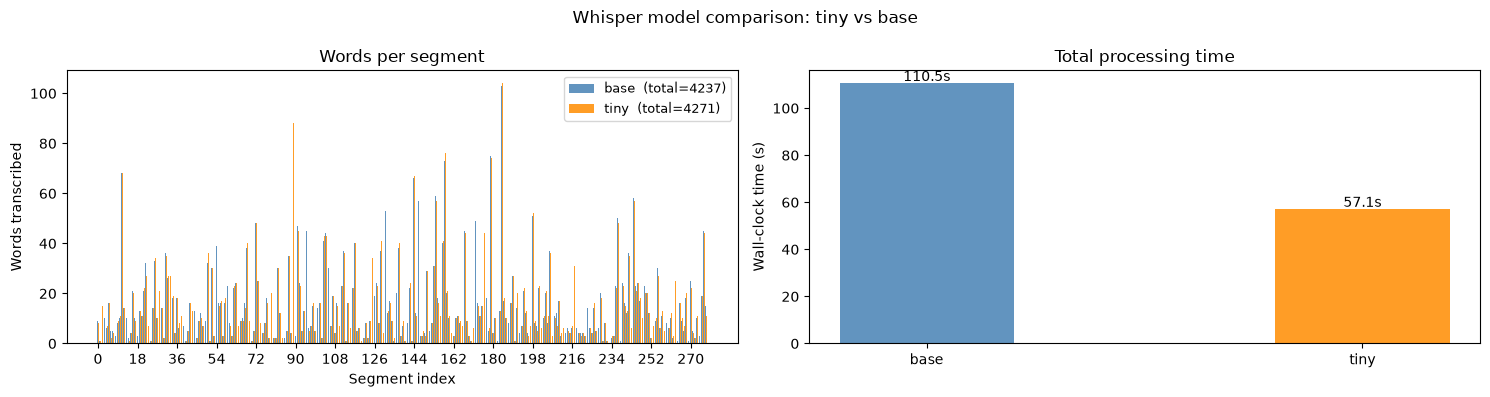

Saved → output/asr/model_comparison.png

Side-by-side transcript comparison (8 segments, evenly spaced):

Seg   0  [10.6s-14.0s]
  base : Does anyone want to see Steve's feedback from there?
  tiny : I want to see Steve's feedback from me.

Seg  39  [218.3s-220.6s]
  base : Okay. The hair's typed into the search.
  tiny : Okay. The hair's typed into the search.

Seg  79  [400.1s-408.6s]
  base : even our results. Yeah, in the night XML, XML format, so with their timestamps and stuff so that it'
  tiny : even our results. In the NIDXMail form, also with the timestamps and stuff that it's used to tie tog

Seg 118  [647.5s-649.0s]
  base : what he meant was not...
  tiny : But he meant was not

Seg 158  [878.9s-898.8s]
  base : Oh yeah, I know why. I mean like how how just mean does it internally? I don't know But it's probabl
  tiny : to where you can eat. Oh yeah, no way. I mean, how just mean does it in turn? Yeah, I don't know, bu

Seg 197  [1120.1s-1122.4s]
  base : We do get an erro

In [8]:
# ── Timing + word-count comparison ────────────────────────────────────────────
words_base = [len(r["words"]) for r in records_base]
words_tiny = [len(r["words"]) for r in records_tiny]

print("=" * 60)
print(f"{'Metric':<30}  {'base':>8}  {'tiny':>8}")
print("=" * 60)
print(f"{'Processing time (s)':<30}  {time_base:>8.1f}  {time_tiny:>8.1f}")
print(f"{'Speed-up (base / tiny)':<30}  {'—':>8}  {time_base/time_tiny:>8.1f}x")
print(f"{'Total words':<30}  {sum(words_base):>8}  {sum(words_tiny):>8}")
print(f"{'Mean words / segment':<30}  {np.mean(words_base):>8.1f}  {np.mean(words_tiny):>8.1f}")
print(f"{'Empty transcripts':<30}  {sum(1 for r in records_base if not r['text']):>8}"
      f"  {sum(1 for r in records_tiny if not r['text']):>8}")
print("=" * 60)

# ── Bar chart: words per segment, both models ─────────────────────────────────
seg_ids = [r["seg_id"] for r in records_base]
x = np.arange(len(seg_ids))
width = 0.4

fig, (ax_bar, ax_time) = plt.subplots(1, 2, figsize=(15, 4))
fig.suptitle("Whisper model comparison: tiny vs base", fontsize=12)

ax_bar.bar(x - width/2, words_base, width, label=f"base  (total={sum(words_base)})", color="steelblue", alpha=0.85)
ax_bar.bar(x + width/2, words_tiny, width, label=f"tiny  (total={sum(words_tiny)})", color="darkorange", alpha=0.85)
ax_bar.set_xlabel("Segment index")
ax_bar.set_ylabel("Words transcribed")
ax_bar.set_title("Words per segment")
ax_bar.legend(fontsize=9)
# tick every ~20 segments so the x-axis stays readable regardless of total count
tick_step = max(1, len(seg_ids) // 15)
ax_bar.set_xticks(x[::tick_step])
ax_bar.set_xticklabels(seg_ids[::tick_step])

# Timing bar
ax_time.bar(["base", "tiny"], [time_base, time_tiny],
            color=["steelblue", "darkorange"], alpha=0.85, width=0.4)
for i, t in enumerate([time_base, time_tiny]):
    ax_time.text(i, t + 1, f"{t:.1f}s", ha="center", fontsize=10)
ax_time.set_ylabel("Wall-clock time (s)")
ax_time.set_title("Total processing time")

plt.tight_layout()
plt.savefig(ASR_OUT / "model_comparison.png", dpi=120)
plt.show()
print("Saved → output/asr/model_comparison.png")

# ── Side-by-side text for 8 segments spread evenly across the full run ─────────
print("\nSide-by-side transcript comparison (8 segments, evenly spaced):\n")
n = len(records_base)
sample_ids = [int(i * (n - 1) / 7) for i in range(8)]   # 0%, 14%, ..., 100%
for idx in sample_ids:
    rb = records_base[idx]
    rt = records_tiny[idx]
    print(f"Seg {rb['seg_id']:3d}  [{rb['start']:.1f}s-{rb['end']:.1f}s]")
    print(f"  base : {rb['text'][:100]}")
    print(f"  tiny : {rt['text'][:100]}")
    print()


---
## Step 4 — Save Output

Output file: `output/asr/EN2001a_asr.json`

**Schema**:
```json
{
  "meeting_id": "EN2001a",
  "model":      "whisper-base",
  "num_segments": 57,
  "segments": [
    {
      "seg_id":   0,
      "start":    10.6,
      "end":      14.0,
      "duration": 3.4,
      "text":     "Right, so I'd like to start ...",
      "words":    [{"word": "Right", "start": 10.61, "end": 10.85}, ...]
    },
    ...
  ]
}
```

Notebook 05 (integration) joins this file with `output/clustering/segments_labeled.json`
to produce the final speaker-labeled transcript.


In [9]:
def save_asr_output(records, meeting_id, model_name, out_dir):
    """
    Persist transcription records to a JSON file.

    Parameters
    ----------
    records    : list[dict]  output of transcribe_segments()
    meeting_id : str
    model_name : str         e.g. 'whisper-base'
    out_dir    : pathlib.Path

    Returns
    -------
    pathlib.Path  path to the saved file
    """
    payload = {
        "meeting_id":   meeting_id,
        "model":        model_name,
        "num_segments": len(records),
        "segments":     records,
    }
    path = out_dir / f"{meeting_id}_asr.json"
    with open(path, "w", encoding="utf-8") as fh:
        json.dump(payload, fh, indent=2, ensure_ascii=False)
    return path


# Save primary (base) output — this is what notebook 05 will read
out_path = save_asr_output(records_base, MEETING_ID,
                           f"whisper-{PRIMARY_MODEL_NAME}", ASR_OUT)
print(f"Primary output saved → {out_path}")
print(f"  Segments : {len(records_base)}")
print(f"  Model    : whisper-{PRIMARY_MODEL_NAME}")

# Save tiny output alongside for reference / notebook 06 comparison
out_path_tiny = save_asr_output(records_tiny, MEETING_ID,
                                f"whisper-{COMPARE_MODEL_NAME}",
                                ASR_OUT)
# Rename to avoid overwriting primary
out_path_tiny = out_path_tiny.rename(
    ASR_OUT / f"{MEETING_ID}_asr_{COMPARE_MODEL_NAME}.json"
)
print(f"Comparison output saved → {out_path_tiny}")
print()
print("Pipeline stage complete.  Next: notebook 05 (integration).")


Primary output saved → output/asr/EN2001a_asr.json
  Segments : 278
  Model    : whisper-base
Comparison output saved → output/asr/EN2001a_asr_tiny.json

Pipeline stage complete.  Next: notebook 05 (integration).
